In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import os

import pandas as pd
import seaborn

from fbio.dataframe import RegionDataFrame
from fbio.fragments_h5 import FragmentsH5

from ravel.fragment_array import RegionFragmentArray, FragmentMatrix, Region, merge_fragment_arrays
from ravel.bio.frag.fragment_matrix import merge_fragment_matrices

In [6]:
base_dir = "/scratch/ctcf_analysis/CTCF/cell_type_merged"
index_cols = ['contig', 'start', 'stop', 'strand']
dfs = []
for fname in os.listdir(base_dir):
    # extract the biosample type from the filename
    cell_type = fname.split('.')[1]
    # load the data into a region dataframe
    df = RegionDataFrame(pd.read_table(os.path.join(base_dir, fname)), ref='hg38')
    # subset the dataframe by the binding site locations
    df = df[['contig', 'start', 'stop', 'strand', 'tf_top_score']].set_index(index_cols)
    # rename the score column to the biosample_type
    df = df.rename(columns={'tf_top_score': cell_type})
    df = df.sort_values(df.columns[0], ascending=False).head(20000).sort_index()
    dfs.append(df)

In [7]:
dfs[0].join(dfs[1], how='outer')

neutrophil  CD8-positive,_alpha-beta_T_cell
contig start    stop     strand                                             
chr1   181743   181760   -        13.180469                        13.180469
       267998   268015   +        11.723959                        11.723959
       586152   586169   +              NaN                        11.785717
       778802   778819   -        12.205630                              NaN
       827356   827373   +        10.401820                              NaN
...                                     ...                              ...
chrY   17430760 17430777 +              NaN                        12.829348
       18669962 18669979 +              NaN                        11.785455
       19433240 19433257 +        12.156856                        12.156856
       20558879 20558896 +        11.929740                        11.929740
       21260537 21260554 -        11.945046                              NaN

[28250 rows x 2 columns]

In [8]:
df = dfs[0]
for i in range(1, len(dfs)): 
    df = df.join(dfs[i], how='outer')
df = pd.DataFrame(df.fillna(0).sort_index())
df = (df > 1e-6).astype(int)

In [9]:
df.head()

neutrophil  CD8-positive,_alpha-beta_T_cell  mucosa_of_descending_colon  B_cell  neural_cell  osteoblast  sigmoid_colon  natural_killer_cell  transverse_colon  stomach  dorsolateral_prefrontal_cortex  CD14-positive_monocyte  neural_crest_cell  neural_progenitor_cell
contig start  stop   strand                                                                                                                                                                                                                                                                            
chr1   91419  91436  +                0                                0                           0       1            1           0              0                    0                 0        0                               0                       0                  0                       0
       181743 181760 -                1                                1                           0       1            0           0              1                    1                 1        0                               1                       1                  1                       1
       267998 268015 +                1                                1                           1       1            1           0              1                    1                 1        1                               1                       1                  0                       0
       586152 586169 +                0                                1                           0       1            0           0              1                    0                 1        0                               1                       1                  0                       0
       609382 609399 +                0                                0                           0       0            0           0              0                    0                 0        0                               0                       0                  0                       1

In [10]:
# neutrophils -- they look weird

In [11]:
df = df.drop(columns='neutrophil')

<AxesSubplot:>

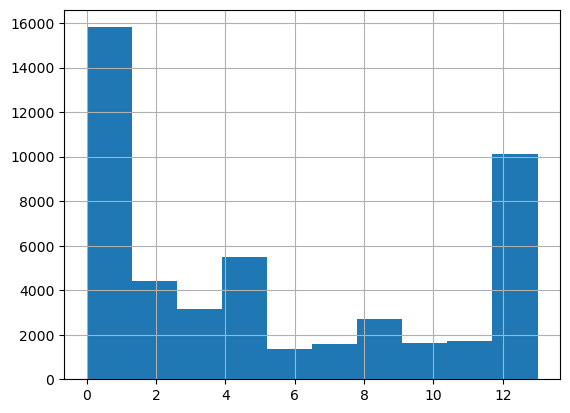

In [12]:
df.sum(axis=1).hist()

In [13]:
# find the boolean mask for regions that are only found in a single cell type. This will be our "off" set
single_site_mask = df.sum(axis=1) == 1
all_bound_mask = df.sum(axis=1) == df.shape[1]
df.loc[single_site_mask, :].sum(axis=0)

CD8-positive,_alpha-beta_T_cell     827
mucosa_of_descending_colon         2698
B_cell                              653
neural_cell                        1185
osteoblast                          843
sigmoid_colon                       491
natural_killer_cell                 684
transverse_colon                    205
stomach                             623
dorsolateral_prefrontal_cortex      573
CD14-positive_monocyte              496
neural_crest_cell                   597
neural_progenitor_cell              610
dtype: int64

In [14]:
# also goinmg to drop mucosa of the colon
# df = df.drop(columns='mucosa_of_descending_colon')

WARNING	2024-01-30 05:37:30,795	/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)



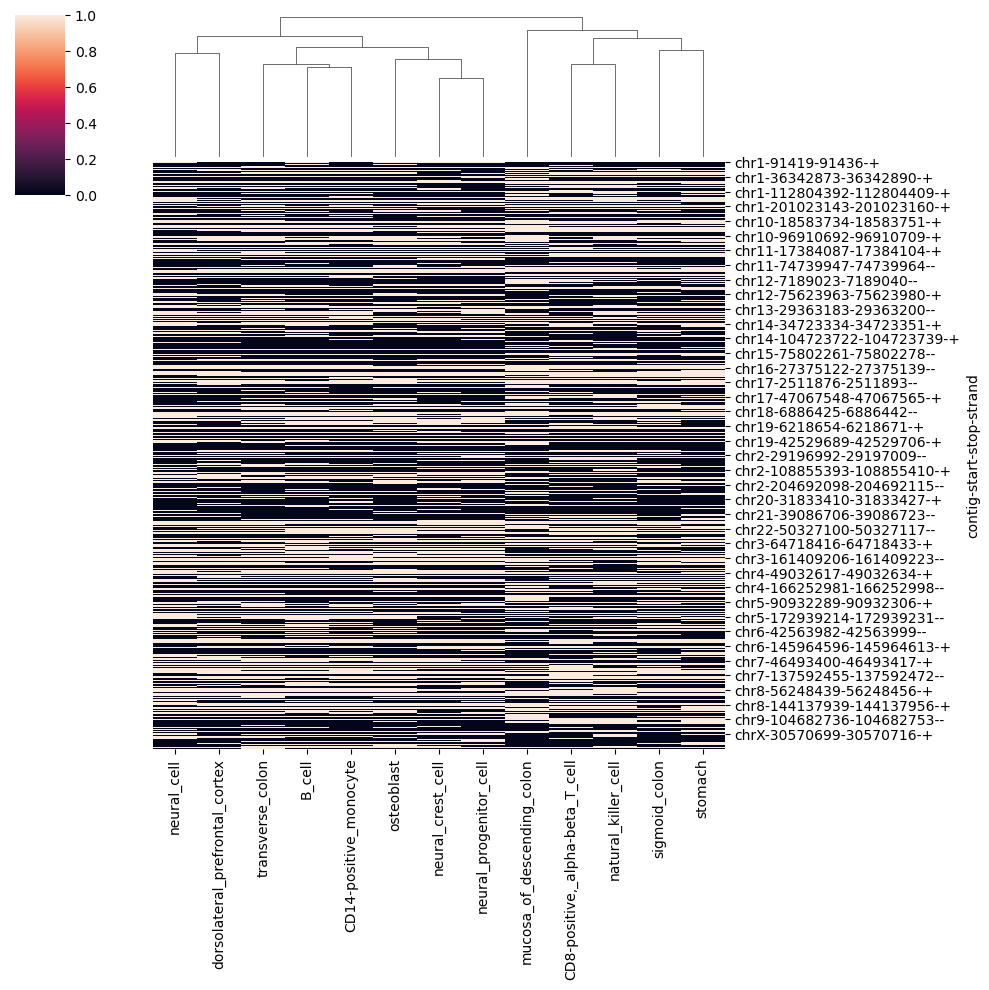

In [15]:
seaborn.clustermap(df, row_cluster=False, figsize=(10, 10))

<AxesSubplot:>

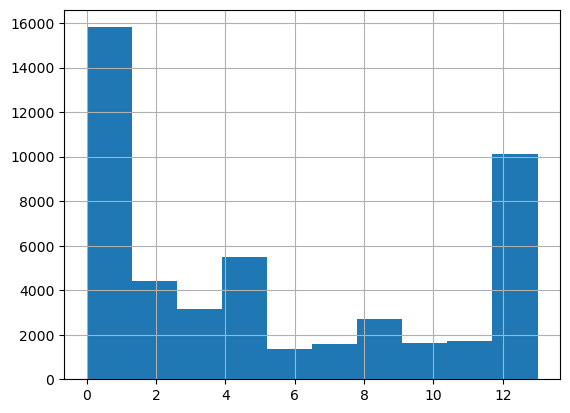

In [16]:
df.sum(axis=1).hist()

In [17]:
# we're excluding one blood and one neural so that the counts remain the same
neural_columns = ['neural_progenitor_cell', 'neural_cell', 'dorsolateral_prefrontal_cortex'] # 'neural_crest_cell', 
colon_columns = ['stomach', 'transverse_colon', 'sigmoid_colon']
blood_columns = ['natural_killer_cell', 'B_cell', 'CD14-positive_monocyte'] # , 'CD8-positive,_alpha-beta_T_cell'
all_columns = neural_columns + colon_columns + blood_columns

all_bnd_mask = (df.sum(axis=1) == df.shape[1])


all_neural_bnd_mask = (df.loc[:, neural_columns].sum(axis=1) >= len(neural_columns))
no_non_neural_bnd_mask = (df.loc[:, colon_columns + blood_columns].sum(axis=1) <= 2)
only_neural_mask = all_neural_bnd_mask&no_non_neural_bnd_mask

all_colon_bnd_mask = (df.loc[:, colon_columns].sum(axis=1) >= len(colon_columns))
no_non_colon_bnd_mask = (df.loc[:, neural_columns + blood_columns].sum(axis=1) <= 2)
only_colon_mask = all_colon_bnd_mask&no_non_colon_bnd_mask

all_blood_bnd_mask = (df.loc[:, blood_columns].sum(axis=1) >= len(blood_columns))
no_non_blood_bnd_mask = (df.loc[:, neural_columns + colon_columns].sum(axis=1) <= 2)
only_blood_mask = all_blood_bnd_mask&no_non_blood_bnd_mask

all_bnd_mask.sum(), only_neural_mask.sum(), only_colon_mask.sum(), only_blood_mask.sum()

(7718, 720, 279, 550)

In [18]:
import glob
sample_ids_to_samples = {}
for fname in glob.glob("/scratch/karius/*.fragments.h5"):
    sample_id = fname.split("/")[3].split('.')[1].split('_')[0][:-5]
    sample_ids_to_samples[sample_id] = fname
    
assert 1 == pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")["SampleID"].value_counts().max()
metadata = pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")
metadata = metadata.query("SampleID in @sample_ids_to_samples.keys()").set_index("SampleID")[['DIAGNOSIS', 'ENDO_CATEGORY', 'Cluster', 'SITE_NUMBER']]
metadata # .iloc[[0]].T

,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER
SampleID,,,,
RD-56150,Ulcerative Colitis,Mild,Patient Group 1,Site_13
RD-56153,Ulcerative Colitis,Mild,Patient Group 2,Site_13
RD-56154,Ulcerative Colitis,Mild,Patient Group 4,Site_13
RD-56155,Ulcerative Colitis,Mild,Patient Group 3,Site_13
RD-56156,Ulcerative Colitis,Mild,Patient Group 1,Site_13
RD-56161,Ulcerative Colitis,Moderate,Patient Group 1,Site_13
RD-56162,Ulcerative Colitis,Moderate,Patient Group 3,Site_13
RD-56163,Ulcerative Colitis,Moderate,Patient Group 3,Site_13
RD-56164,Ulcerative Colitis,Moderate,Patient Group 2,Site_13


<AxesSubplot:>

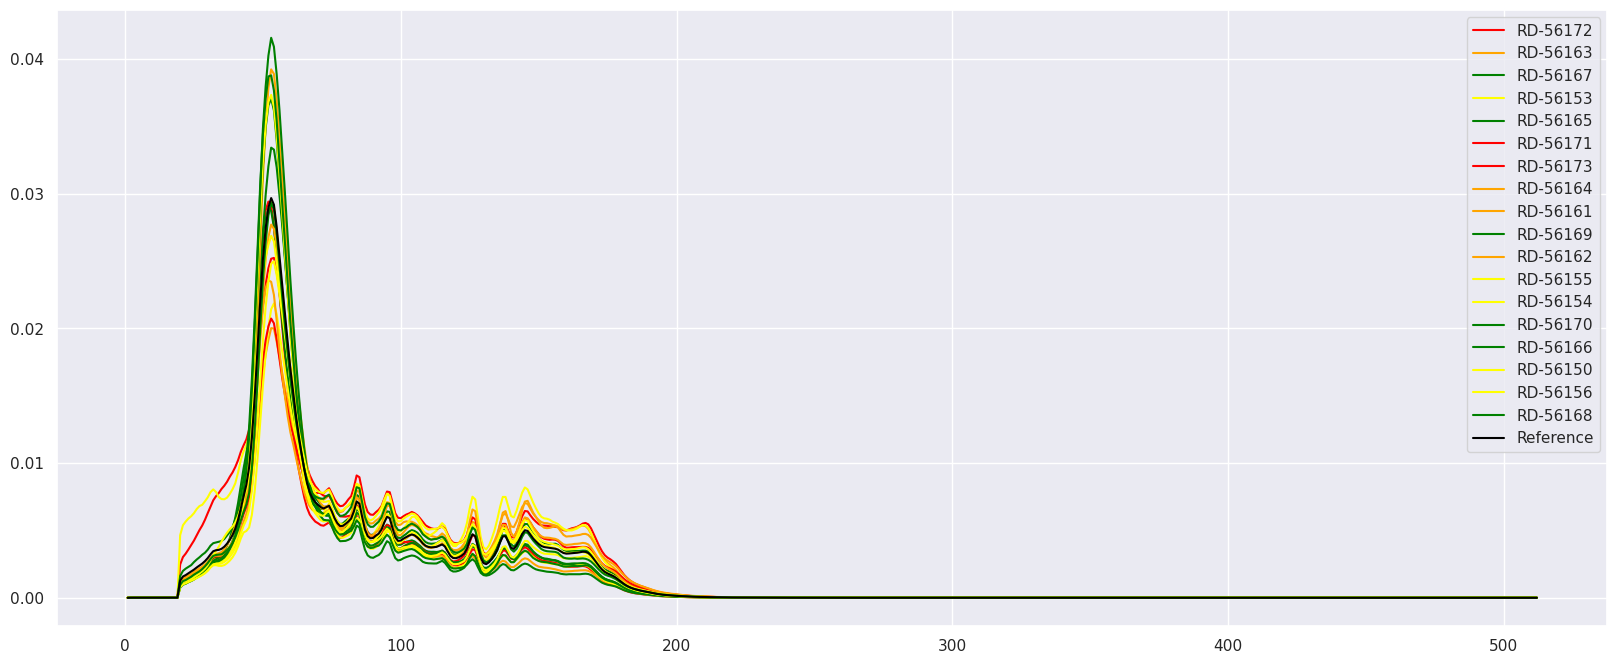

In [19]:
import seaborn as sns
import numpy as np

color_mapping = dict(Severe='red', Moderate='orange', Mild='yellow', Remission='green')

max_frag_len = 512
sns.set(rc={'figure.figsize':(20, 8)})
columns = {}
for sample_id, fname in sample_ids_to_samples.items():
    cnts = FragmentsH5(fname).fragment_length_counts[:max_frag_len]
    # normalize to library depth
    cnts = cnts/cnts.sum()
    columns[sample_id] = cnts

fl_df = pd.DataFrame(columns)
fl_df = fl_df.set_index(fl_df.index+1)

ref_fl_dist = fl_df.mean(axis=1)
ref_fl_dist = ref_fl_dist/ref_fl_dist.sum()

colors = [color_mapping[x] for x in metadata.loc[fl_df.columns].ENDO_CATEGORY.tolist()]

fl_df.loc[:, 'Reference'] = ref_fl_dist
colors.append('black')

fl_df.plot(color=colors)

In [20]:
fl_df

,RD-56172,RD-56163,RD-56167,RD-56153,RD-56165,RD-56171,RD-56173,RD-56164,RD-56161,RD-56169,RD-56162,RD-56155,RD-56154,RD-56170,RD-56166,RD-56150,RD-56156,RD-56168,Reference
1,5.949151e-07,4.314227e-07,5.385034e-07,5.624770e-07,0.000001,0.000001,6.031787e-07,6.005924e-07,6.969642e-07,5.074389e-07,0.000001,9.024162e-07,6.608165e-07,6.458258e-07,0.000001,0.000001,6.058446e-07,9.381237e-07,7.938095e-07
2,9.622370e-06,4.267526e-06,6.223323e-06,7.816989e-06,0.000038,0.000009,5.553619e-06,6.969952e-06,1.595073e-05,1.170248e-05,0.000012,6.112242e-06,1.052197e-05,1.173747e-05,0.000017,0.000011,1.248852e-05,8.099780e-06,1.130346e-05
3,8.945082e-06,3.960638e-06,5.496066e-06,7.488156e-06,0.000036,0.000007,4.966067e-06,6.098323e-06,1.504070e-05,1.089686e-05,0.000011,5.200522e-06,8.747303e-06,1.062135e-05,0.000016,0.000010,1.092706e-05,7.538840e-06,1.031384e-05
4,9.549150e-06,4.125201e-06,6.004036e-06,7.237205e-06,0.000038,0.000007,5.584872e-06,6.803634e-06,1.578461e-05,1.128659e-05,0.000012,5.754066e-06,9.397900e-06,1.078032e-05,0.000015,0.000009,1.190766e-05,7.780624e-06,1.072762e-05
5,1.029051e-05,4.452104e-06,6.237202e-06,7.727569e-06,0.000040,0.000008,6.038037e-06,6.966872e-06,1.678853e-05,1.208175e-05,0.000012,5.637776e-06,1.059350e-05,1.158512e-05,0.000017,0.000010,1.266653e-05,8.534992e-06,1.153516e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,1.168474e-06,7.672207e-07,9.854058e-07,9.663067e-07,0.000003,0.000002,7.625679e-07,1.059507e-06,1.783939e-06,1.467388e-06,0.000002,9.210227e-07,1.216039e-06,1.414193e-06,0.000002,0.000001,1.439662e-06,1.141223e-06,1.346753e-06
509,1.134915e-06,7.427586e-07,9.493205e-07,1.021112e-06,0.000003,0.000001,7.469415e-07,9.886675e-07,1.841719e-06,1.470003e-06,0.000001,9.256744e-07,1.318227e-06,1.195606e-06,0.000002,0.000001,1.630159e-06,1.112209e-06,1.348330e-06
510,1.333220e-06,7.805637e-07,9.715268e-07,1.110532e-06,0.000003,0.000001,8.219481e-07,8.901088e-07,1.910332e-06,1.443847e-06,0.000001,7.814738e-07,1.222851e-06,1.374450e-06,0.000002,0.000001,1.367835e-06,1.262115e-06,1.346014e-06
511,1.220339e-06,7.027297e-07,1.004836e-06,9.259238e-07,0.000003,0.000001,8.188229e-07,9.455481e-07,1.599768e-06,1.307832e-06,0.000001,9.628874e-07,1.434040e-06,1.122743e-06,0.000002,0.000001,1.458399e-06,1.010659e-06,1.260739e-06


In [24]:
# frag_h5 = FragmentsH5("/scratch/karius/finished.fragments.h5") # "/scratch/test_samples/SEQRUN48_LIBRARY577.fragments.h5")
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = metadata.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')
max_num_samples = 3

from fbio.plot.tracks import CoverageTrack, VLine, Tracks
def make_tracks(fm):
    first_nuc=135
    offset=175
    tracks = fm.make_tracks(sum_pool_by=2)
    del tracks[:]
    #tracks.append(CoverageTrack(fm, fm.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=None, smooth_window=5, vlines=[VLine(x=512-25)], name='left endpoint') 
    #              + CoverageTrack(fm, fm.plot_region, coverage_type='right_endpoint', n_boot_coverage=0, fraction=None, smooth_window=5, vlines=[VLine(x=512+25)], name='right endpoint'))
    tracks.append(CoverageTrack(fm, fm.plot_region, coverage_type='midpoint', fraction=(0, 110), smooth_window=20, ylim=(None, None),
                                vlines=[VLine(x=512)], 
                                name='sub-nucleosome (< 110)'))
    tracks.append(CoverageTrack(fm, fm.plot_region, coverage_type='midpoint', n_boot_coverage=20, fraction=(110, 500), smooth_window=50, ylim=None, #  ylim=(2.5, 7.5),
                                vlines=[VLine(x=512+x) for x in (-first_nuc-2*offset, -first_nuc-offset, -first_nuc, first_nuc, first_nuc+offset, first_nuc+2*offset)], 
                                name='nucleosome (> 110)'))
    return tracks

def fm_from_regions_mask(_mask, frag_h5):
    sub_db = RegionDataFrame(df.loc[_mask, :].index.to_frame().reset_index(drop=True), ref='hg38')
    regions = list(sub_db.iter_regions())
    fas = [RegionFragmentArray.from_fragments_h5(frag_h5, r.resize(1024)) for r in regions]
    fm = merge_fragment_arrays(fas).fragment_matrix

    # calculate the fl acceptance probs
    if False:
        fl_cnts = frag_h5.fragment_length_counts[:max_frag_len].clip(1)
        norm_fl_cnts = fl_cnts / fl_cnts.sum()
        scaling_factor = (ref_fl_dist/norm_fl_cnts).max()
        sample_acceptance_prbs = ref_fl_dist/(scaling_factor*norm_fl_cnts)
        fm = fm.downsampled_frag_lens(sample_acceptance_prbs.round(6))

    fm = fm.downsampled(5000)
    return fm

def fm_from_regions_mask_and_severity(severity, _mask):
    assert severity in severities
    fms = []
    selected_metadata = metadata.query(f"ENDO_CATEGORY == '{severity}'").query("Cluster in @patient_groups").sample(n=max_num_samples)
    for sample_id in selected_metadata.index.tolist():
        frag_h5 = FragmentsH5(sample_ids_to_samples[sample_id])
        fms.append(fm_from_regions_mask(_mask, frag_h5))
    return merge_fragment_matrices(fms)

(<Figure size 2500x400 with 2 Axes>,
 [<AxesSubplot:title={'center':'Blood'}>,
  <AxesSubplot:title={'center':'Colon'}, xlabel='NA'>])

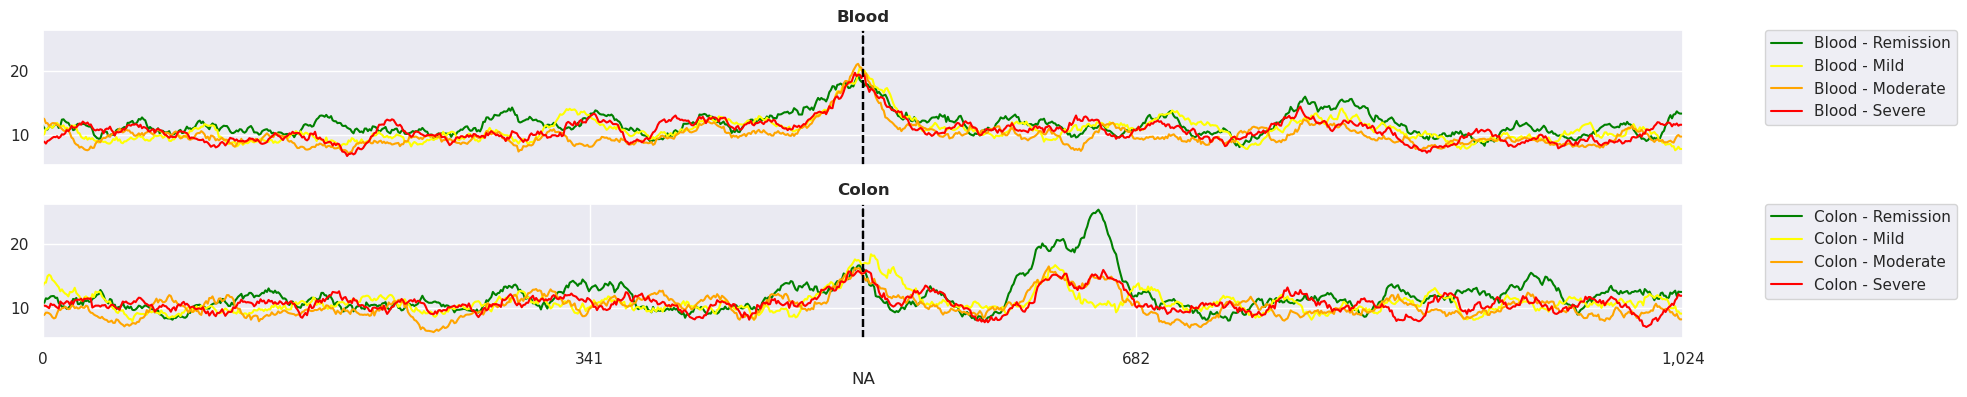

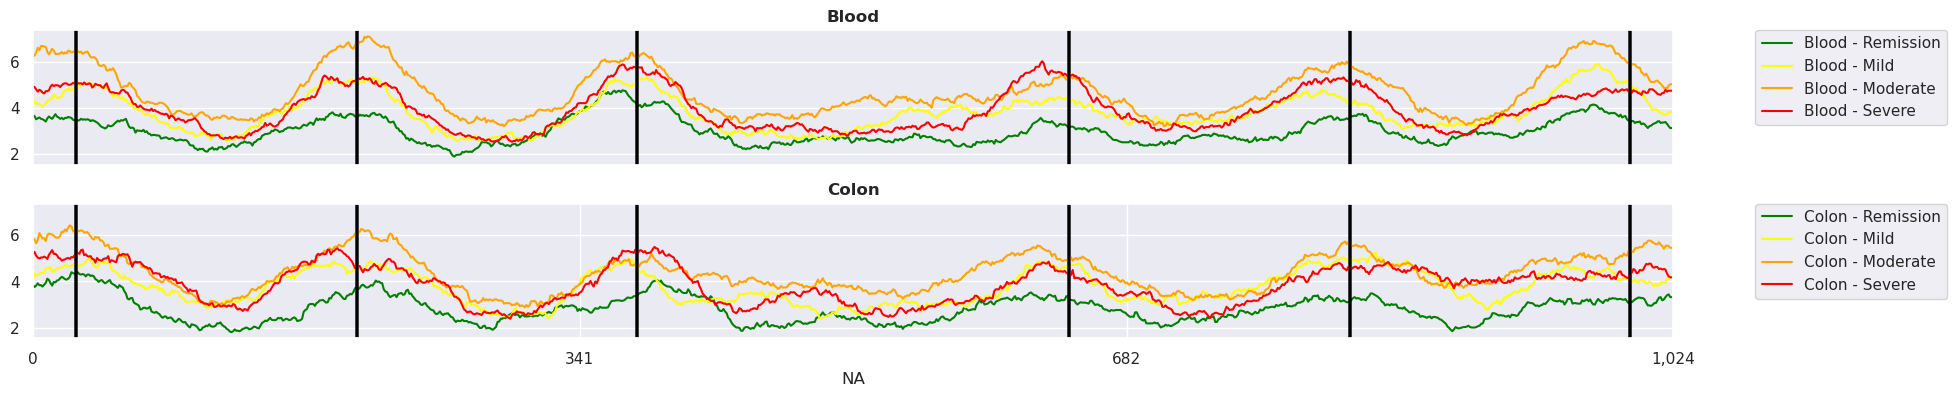

In [22]:
first_nuc=135
offset=175

all_sub_tracks = Tracks()
all_nuc_tracks = Tracks()


for (cell_type_label, cell_type_mask) in [('Blood', only_blood_mask), ('Colon', only_colon_mask)]: # , ('Neural', only_neural_mask), ('All', all_bnd_mask)]:
    sub_nuc_tracks = []
    nuc_tracks = []
    for severity in severities:
        fm = fm_from_regions_mask_and_severity(severity, cell_type_mask)
        sub_nuc_tracks.append(
            CoverageTrack(fm, fm.plot_region, 
                          coverage_type='midpoint', fraction=(0, 110), smooth_window=20, 
                          n_boot_coverage=0,
                          ylim=(None, None),
                          vlines=[VLine(x=512, linestyle='dashed', alpha=0.2, linewidth=0.3)],
                          name=f'{cell_type_label} - {severity}',
                          color=color_mapping[severity],
            ))

        nuc_tracks.append(
            CoverageTrack(fm, fm.plot_region, 
                          coverage_type='midpoint', fraction=(110, 500), smooth_window=50, 
                          n_boot_coverage=0,
                          ylim=None, #  ylim=(2.5, 7.5),
                          vlines=[VLine(x=512+x) for x in (-first_nuc-2*offset, -first_nuc-offset, -first_nuc, first_nuc, first_nuc+offset, first_nuc+2*offset)], 
                          name=f'{cell_type_label} - {severity}',
                          color=color_mapping[severity],
            ))

    sub_nuc_track = sum(sub_nuc_tracks)
    sub_nuc_track.name = cell_type_label
    nuc_track = sum(nuc_tracks)
    nuc_track.name = cell_type_label

    all_sub_tracks.append(sub_nuc_track)
    all_nuc_tracks.append(nuc_track)

all_sub_tracks.plot(sharey=True)
all_nuc_tracks.plot(sharey=True)

#make_tracks(fm_from_regions_mask_and_severity('Remission', only_blood_mask)) # .plot(title='Blood -- Remission')
#make_tracks(fm_from_regions_mask_and_severity('Mild', only_blood_mask)) # .plot(title='Blood -- Mild')
#make_tracks(fm_from_regions_mask_and_severity('Moderate', only_blood_mask)) # .plot(title='Blood -- Moderate')
#make_tracks(fm_from_regions_mask_and_severity('Severe', only_blood_mask)).plot(title='Blood -- Severe')

(<Figure size 2500x1600 with 8 Axes>,
 [<AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

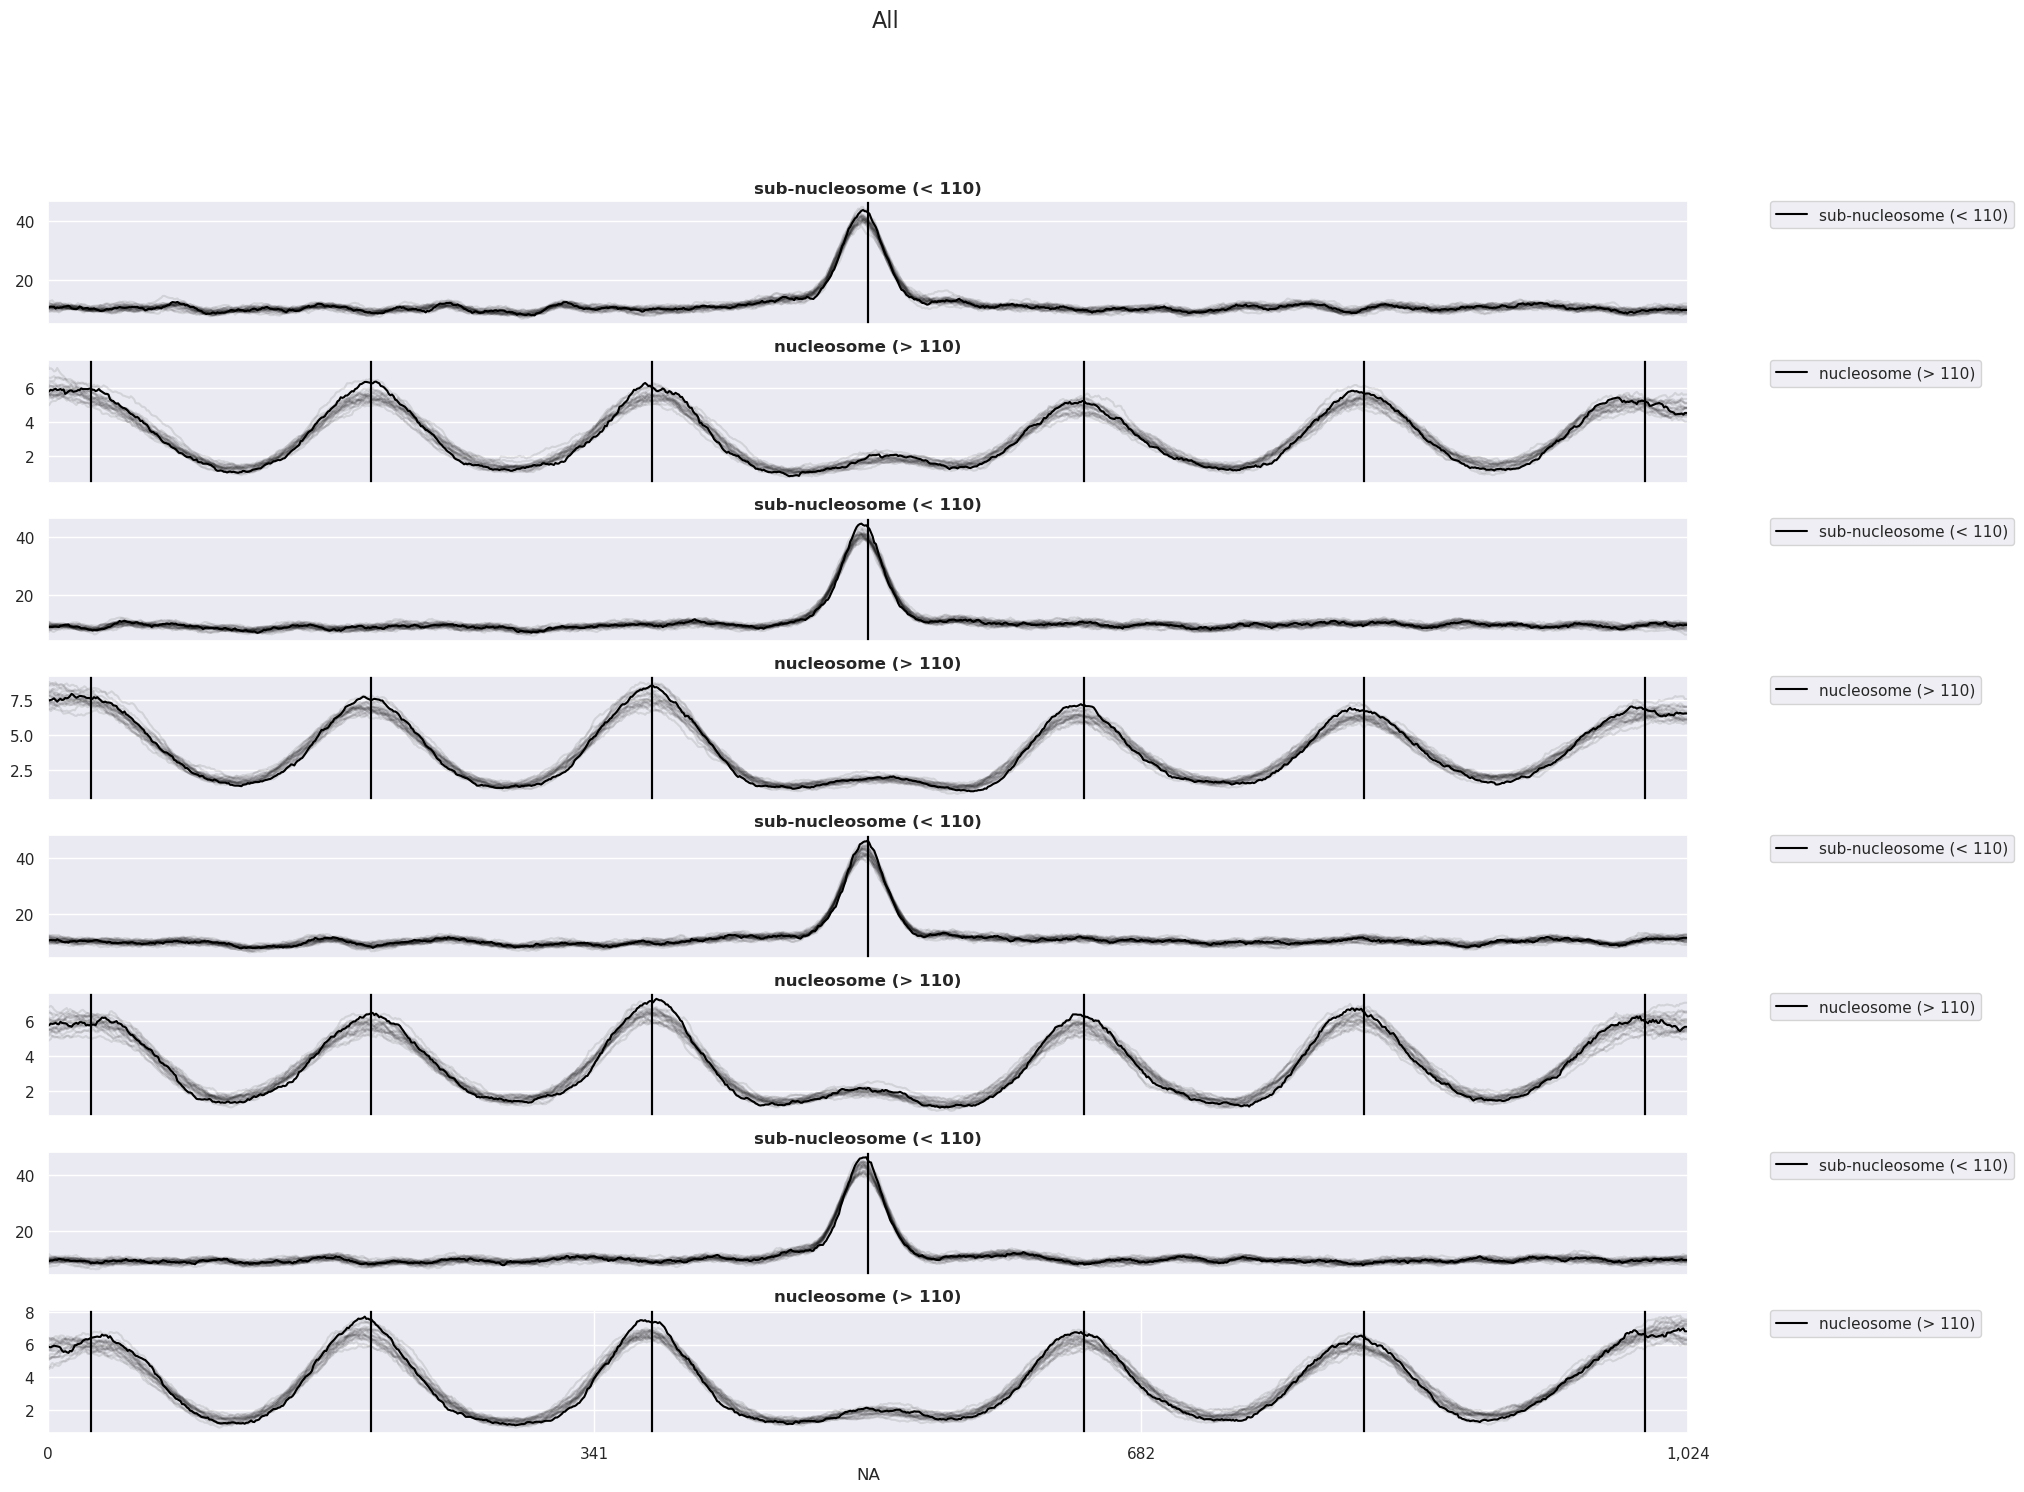

In [23]:
all_tracks = Tracks()
for sev in severities:
    all_tracks.extend(make_tracks(fm_from_regions_mask_and_severity(sev, all_bnd_mask))) # .plot(title='Blood -- Remission')
all_tracks.plot(title='All')

(<Figure size 2500x800 with 5 Axes>,
 [<AxesSubplot:title={'center':' 22500 frags'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

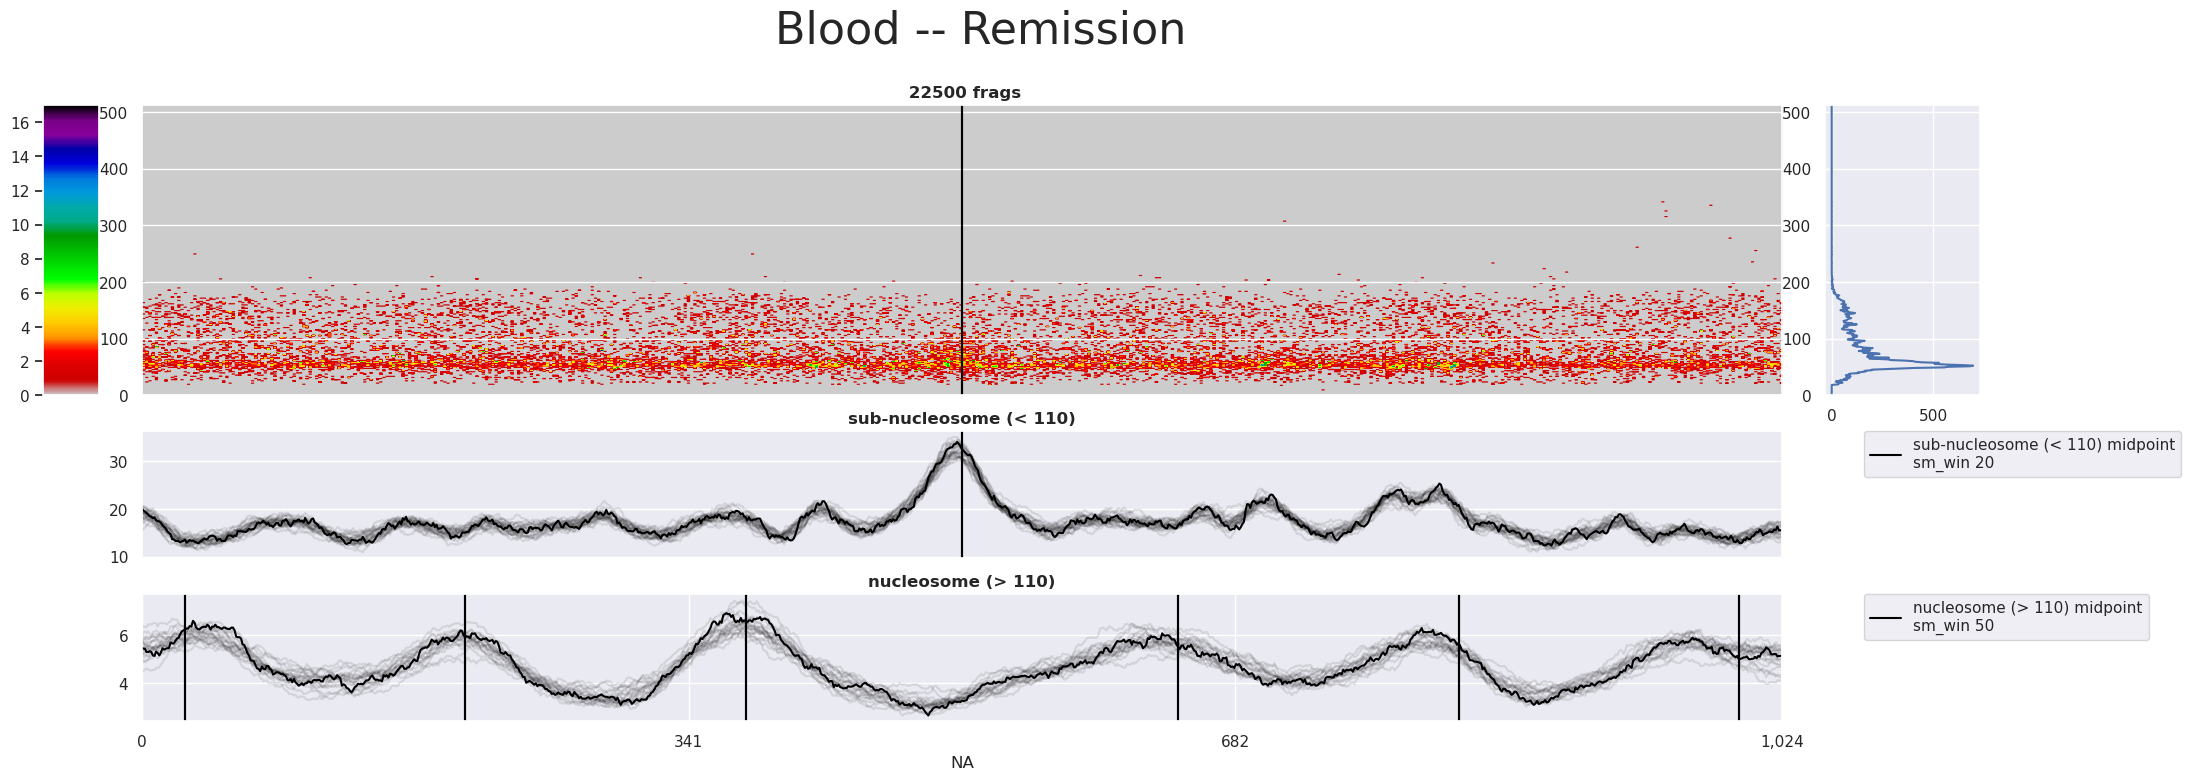

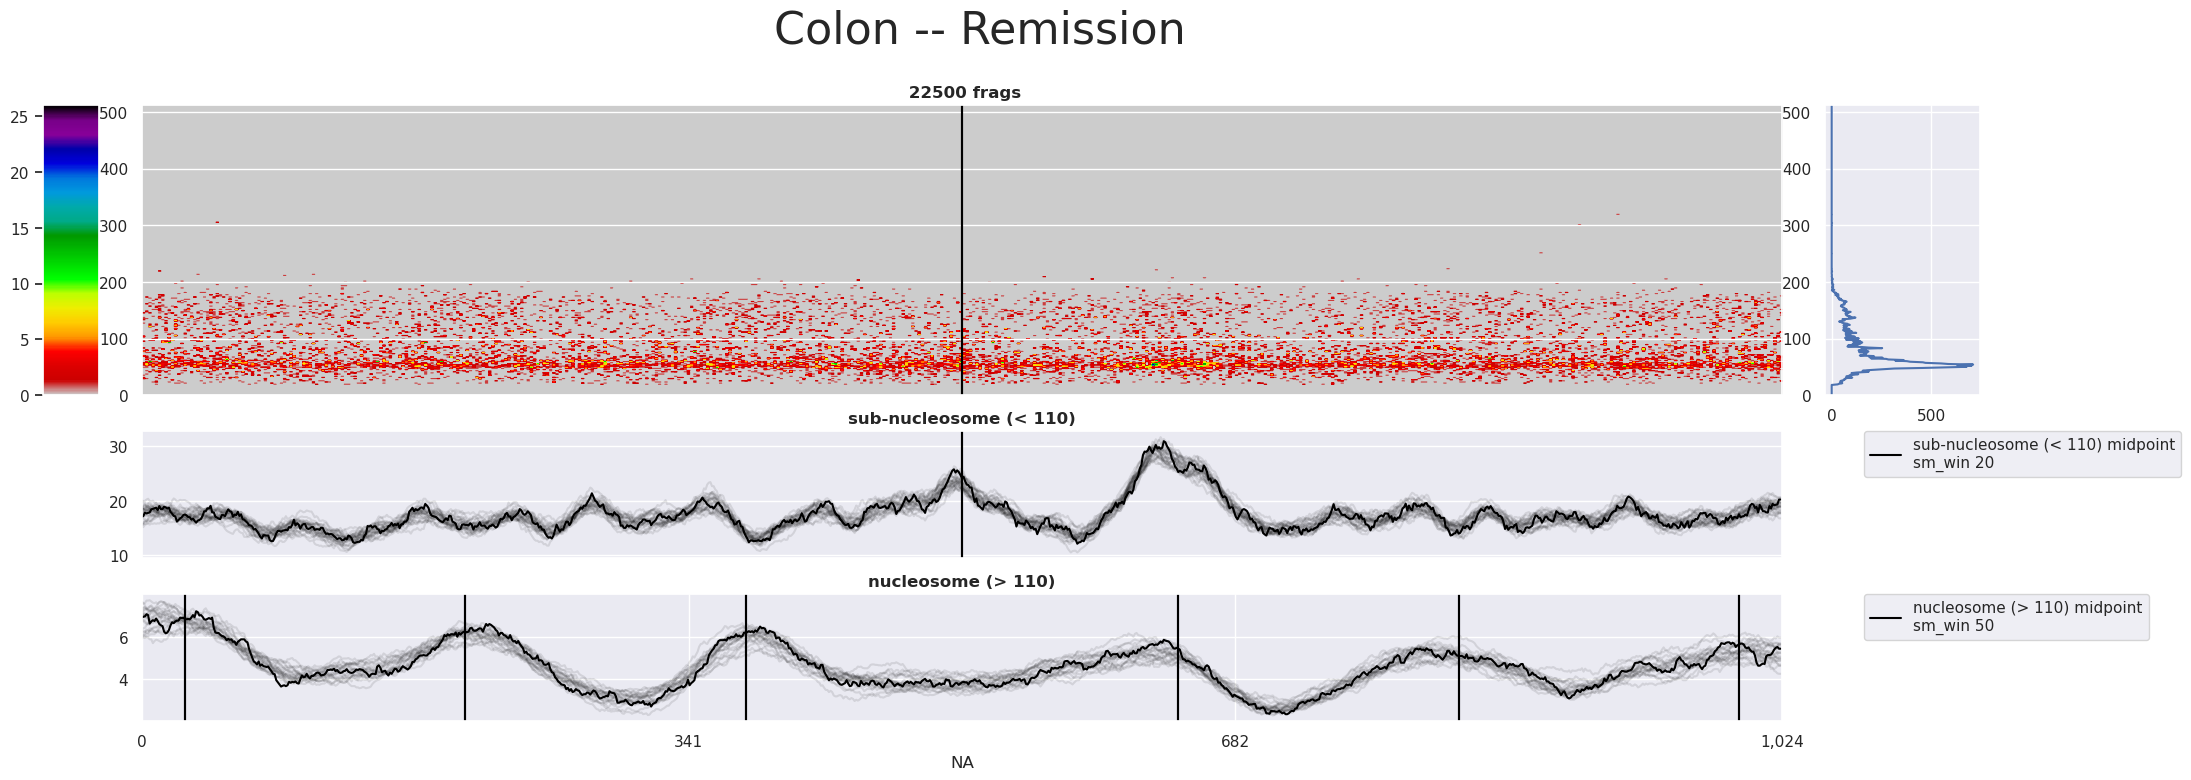

In [222]:
make_tracks(fm_from_regions_mask_and_severity('Remission', only_blood_mask)).plot(title='Blood -- Remission')
make_tracks(fm_from_regions_mask_and_severity('Remission', only_colon_mask)).plot(title='Colon -- Remission')

In [223]:
#make_tracks(fm_from_regions_mask_and_severity('Mild', only_blood_mask)).plot(title='Blood -- Mild')
#make_tracks(fm_from_regions_mask_and_severity('Mild', only_colon_mask)).plot(title='Colon -- Mild')

In [224]:
#make_tracks(fm_from_regions_mask_and_severity('Moderate', only_blood_mask)).plot(title='Blood -- Moderate')
#make_tracks(fm_from_regions_mask_and_severity('Moderate', only_colon_mask)).plot(title='Colon -- Moderate')

(<Figure size 2500x800 with 5 Axes>,
 [<AxesSubplot:title={'center':' 22500 frags'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

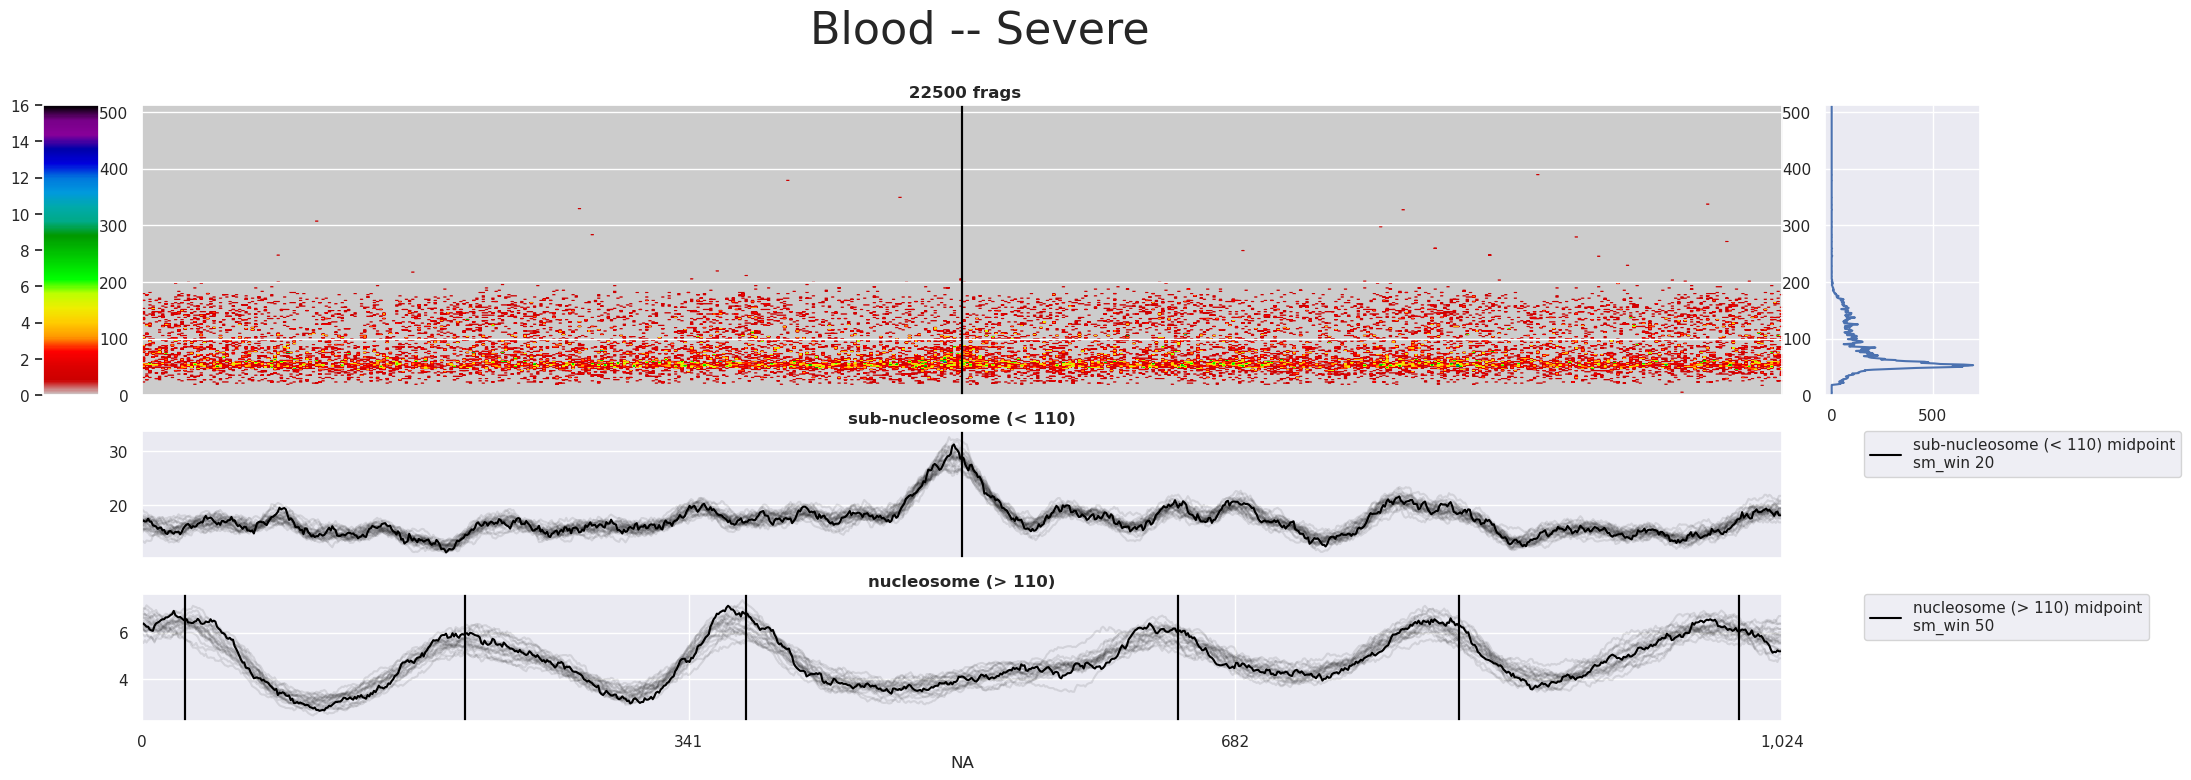

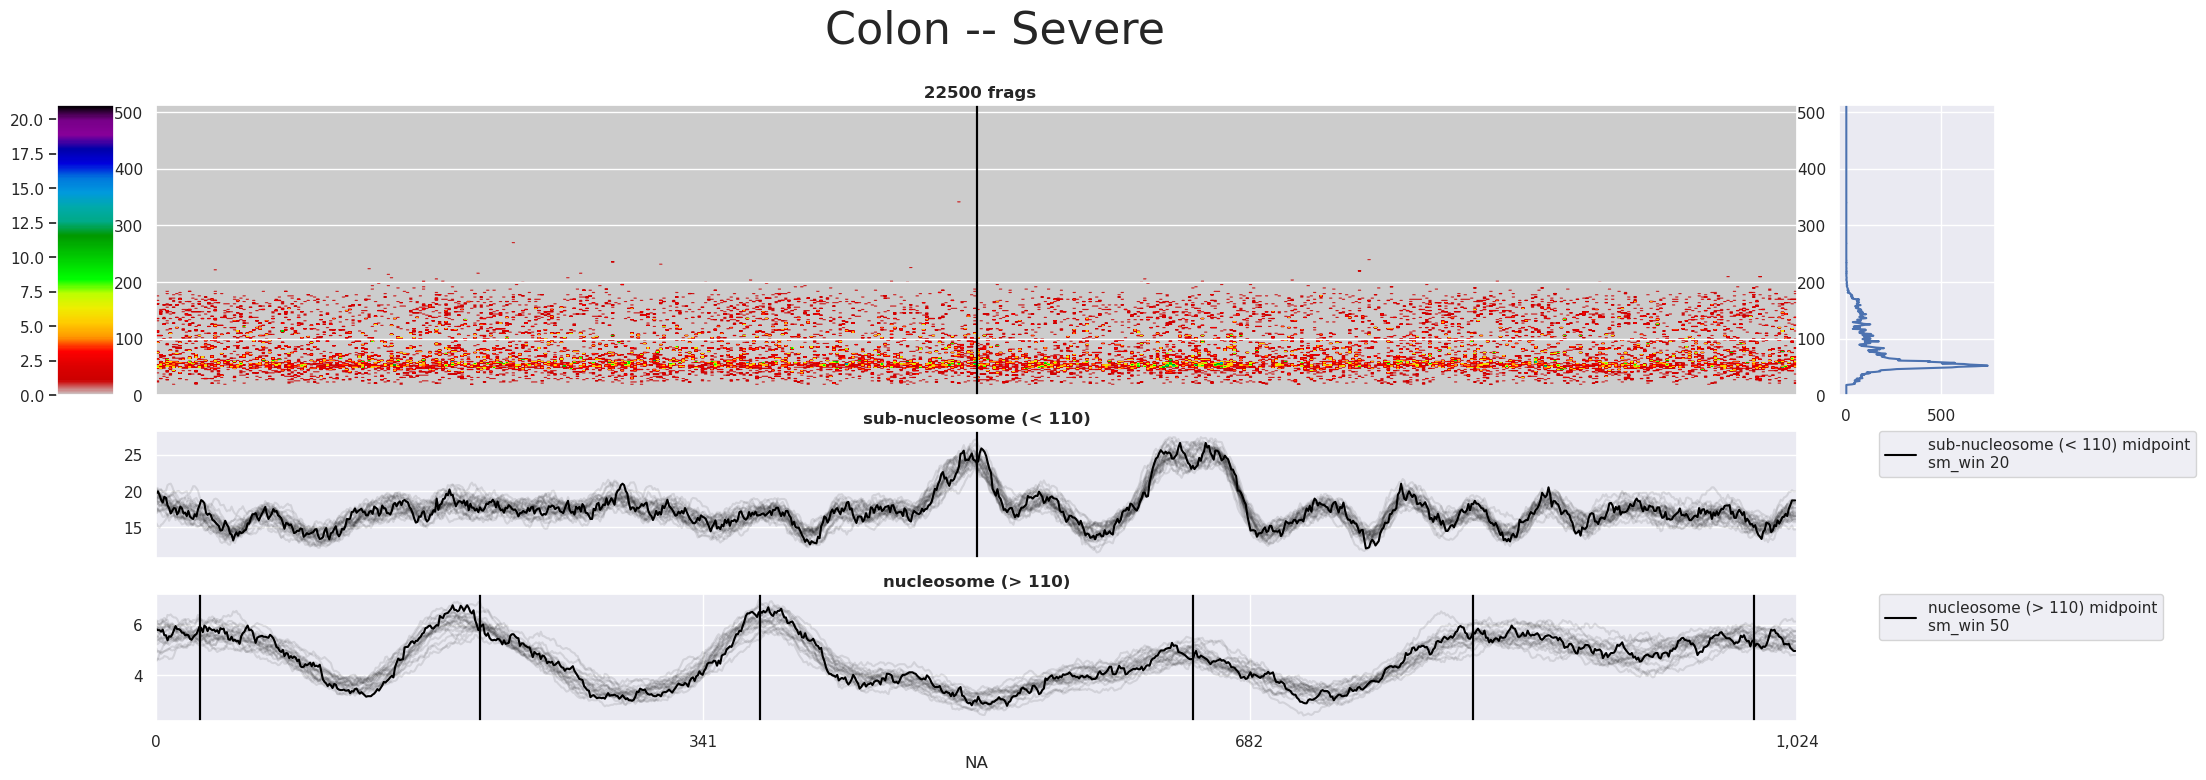

In [225]:
make_tracks(fm_from_regions_mask_and_severity('Severe', only_blood_mask)).plot(title='Blood -- Severe')
make_tracks(fm_from_regions_mask_and_severity('Severe', only_colon_mask)).plot(title='Colon -- Severe')

CPU times: user 2.65 s, sys: 67.9 ms, total: 2.71 s
Wall time: 2.71 s


(<Figure size 2500x1000 with 6 Axes>,
 [<AxesSubplot:title={'center':' 10000 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

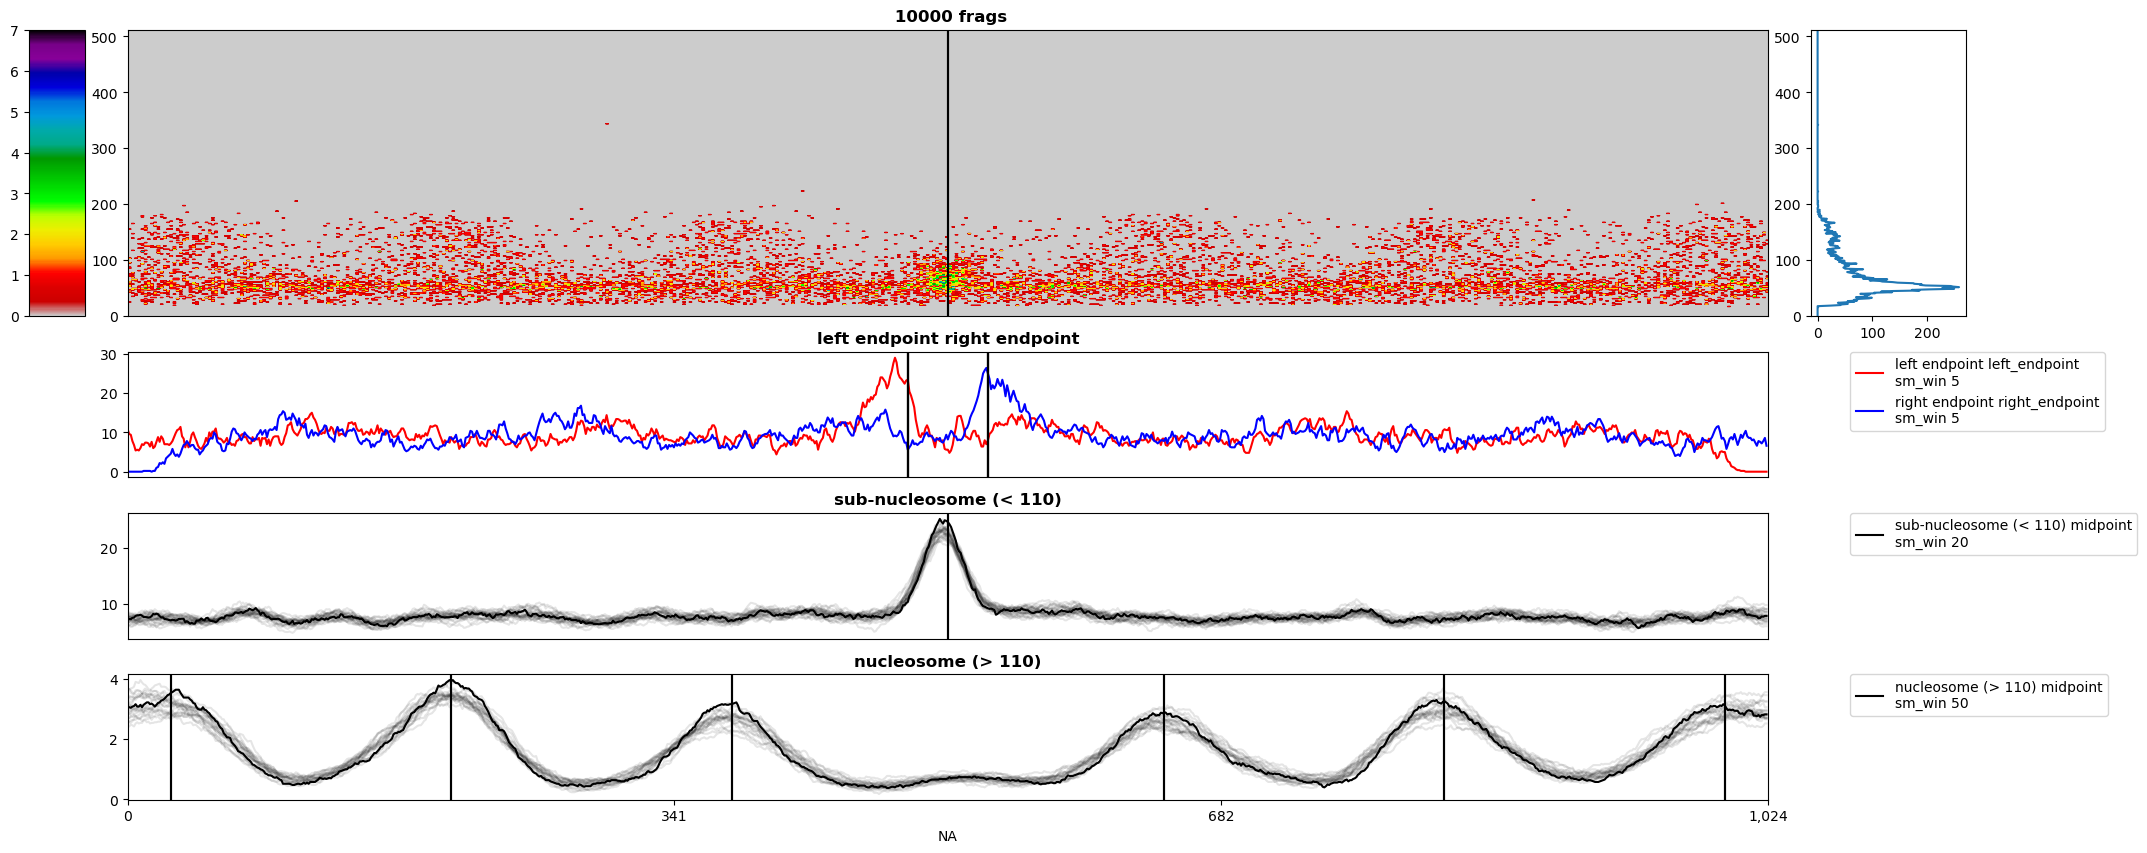

In [124]:
%%time
make_tracks(fm_from_regions_mask(all_bound_mask)).plot()

KeyError: "None of [Index(['neural_progenitor_cell', 'neural_cell', 'dorsolateral_prefrontal_cortex'], dtype='object')] are in the [columns]"

(<Figure size 2500x1000 with 6 Axes>,
 [<AxesSubplot:title={'center':' 10000 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

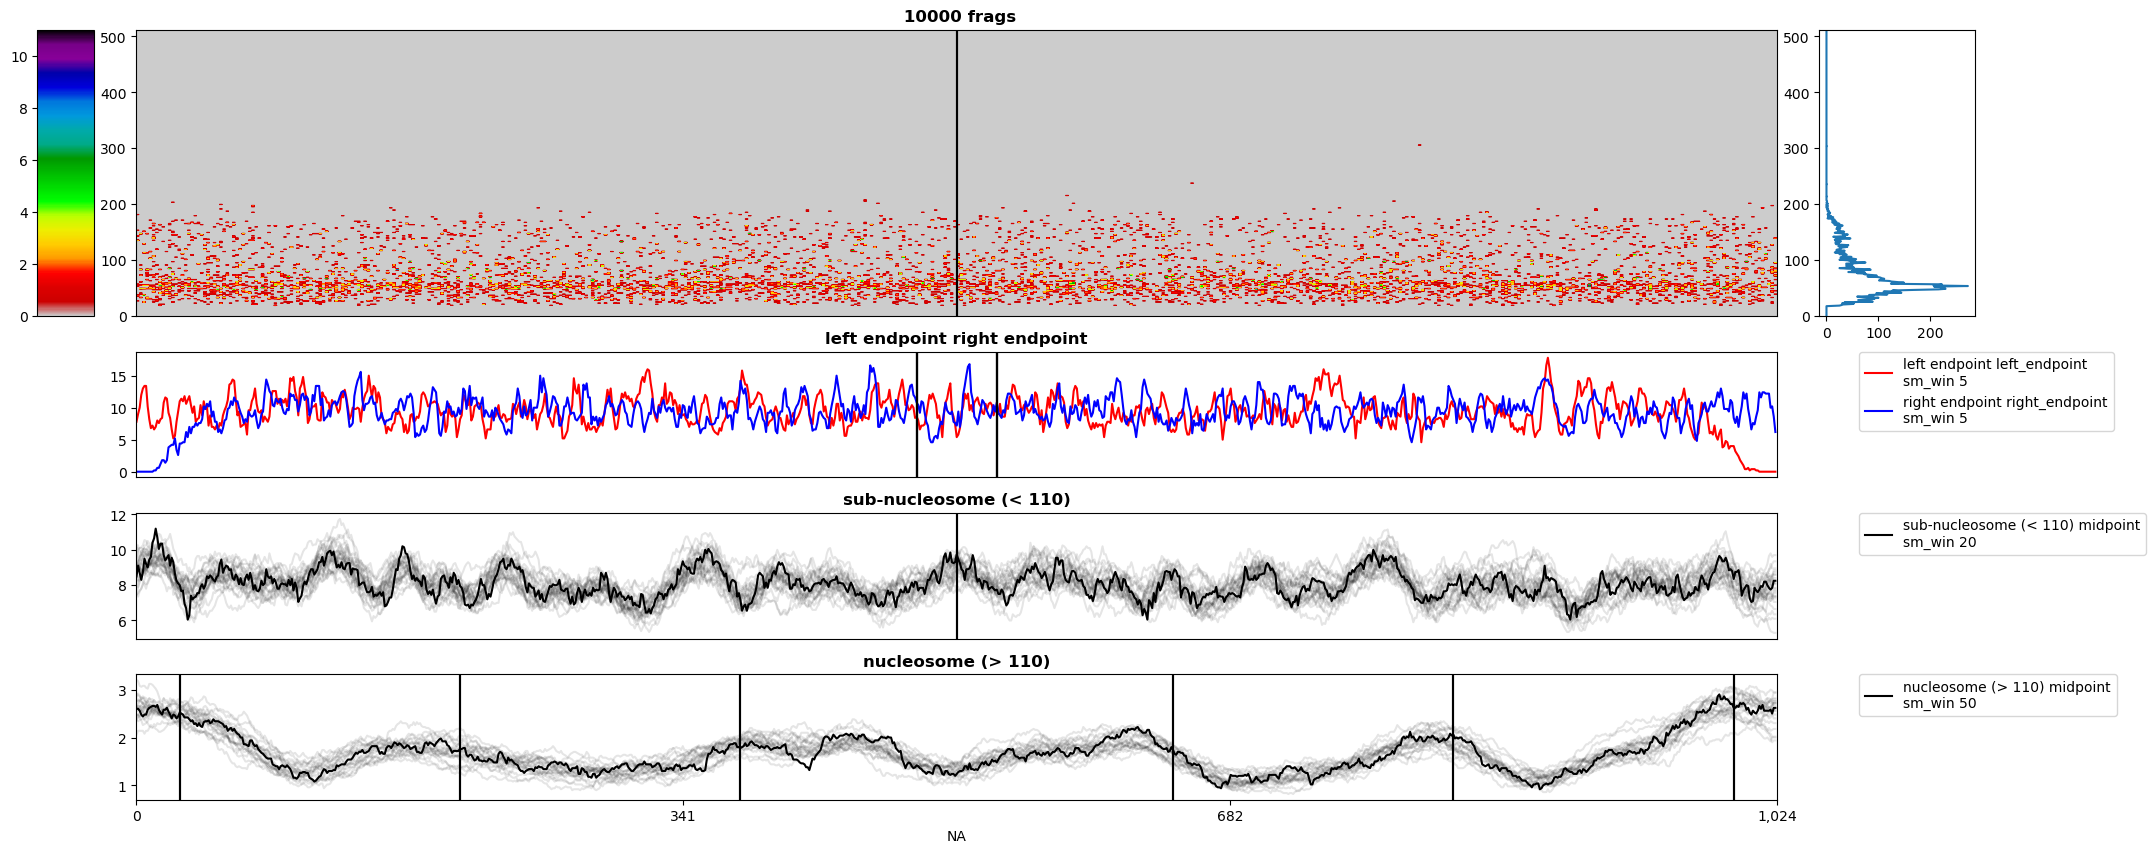

In [126]:
make_tracks(fm_from_regions_mask(only_neural_mask)).plot()

(<Figure size 2500x1000 with 6 Axes>,
 [<AxesSubplot:title={'center':' 10000 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

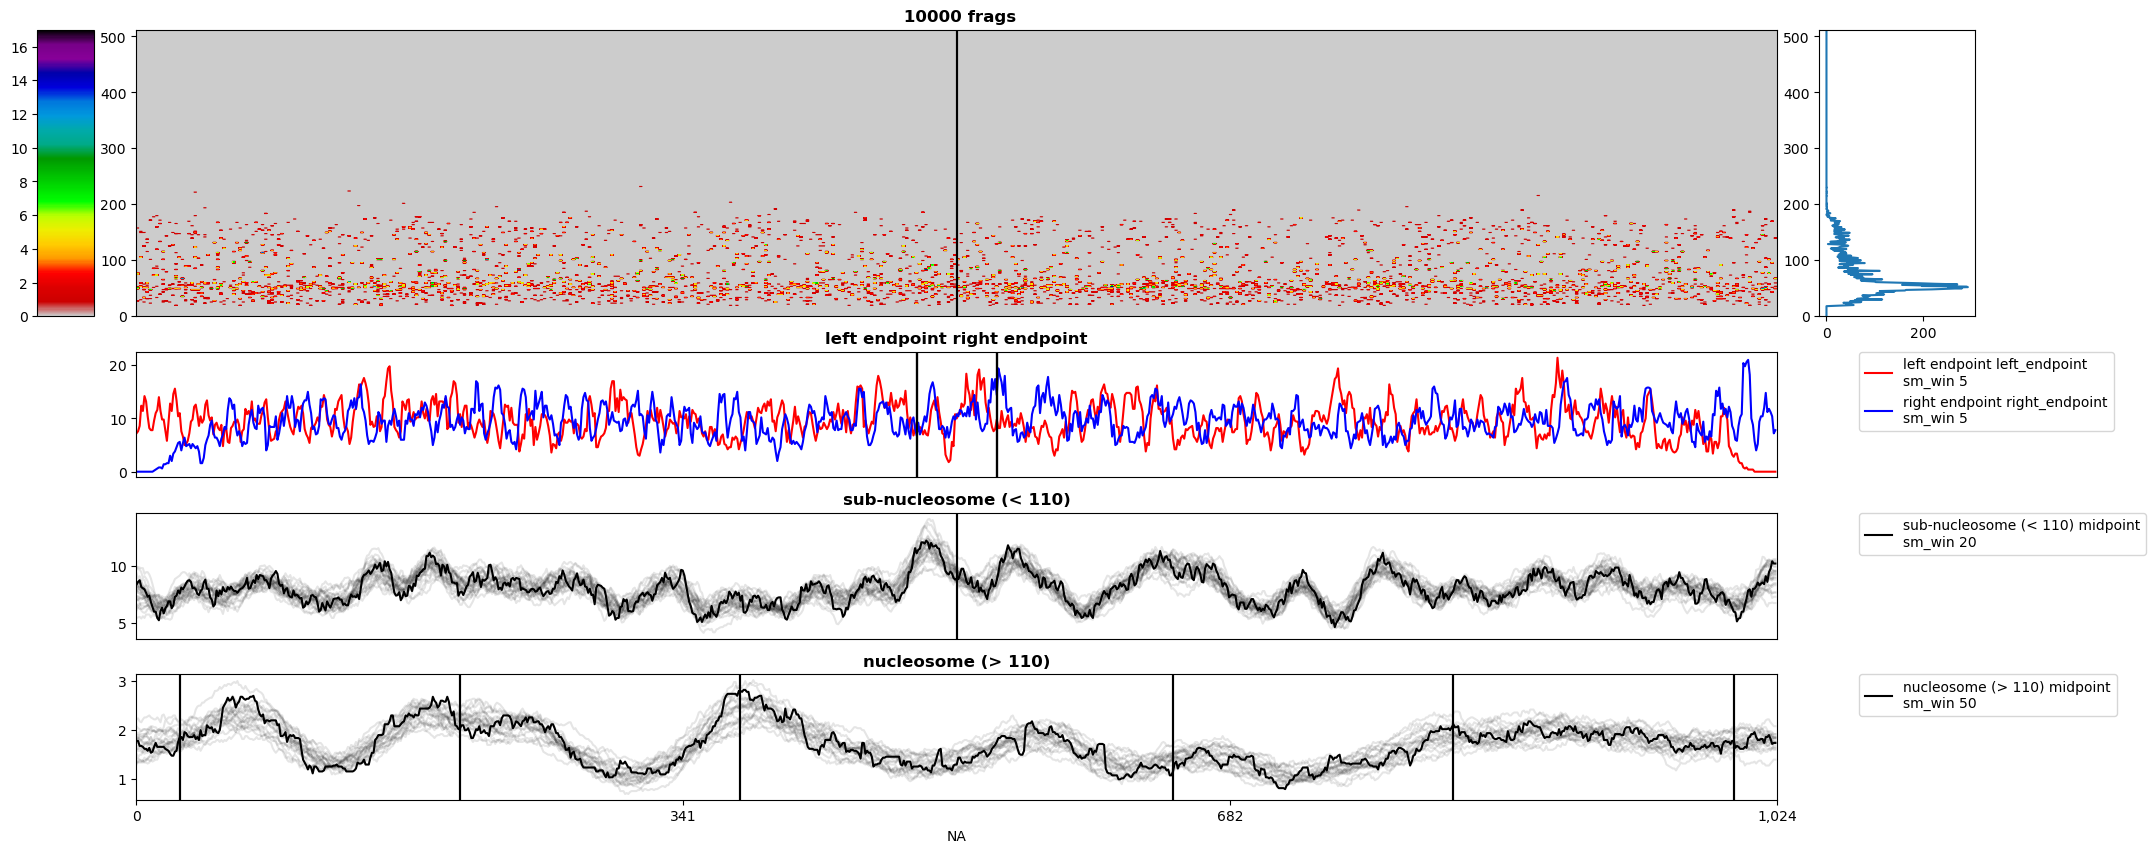

In [127]:
make_tracks(fm_from_regions_mask(only_colon_mask)).plot()

(<Figure size 2500x1000 with 6 Axes>,
 [<AxesSubplot:title={'center':' 10000 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

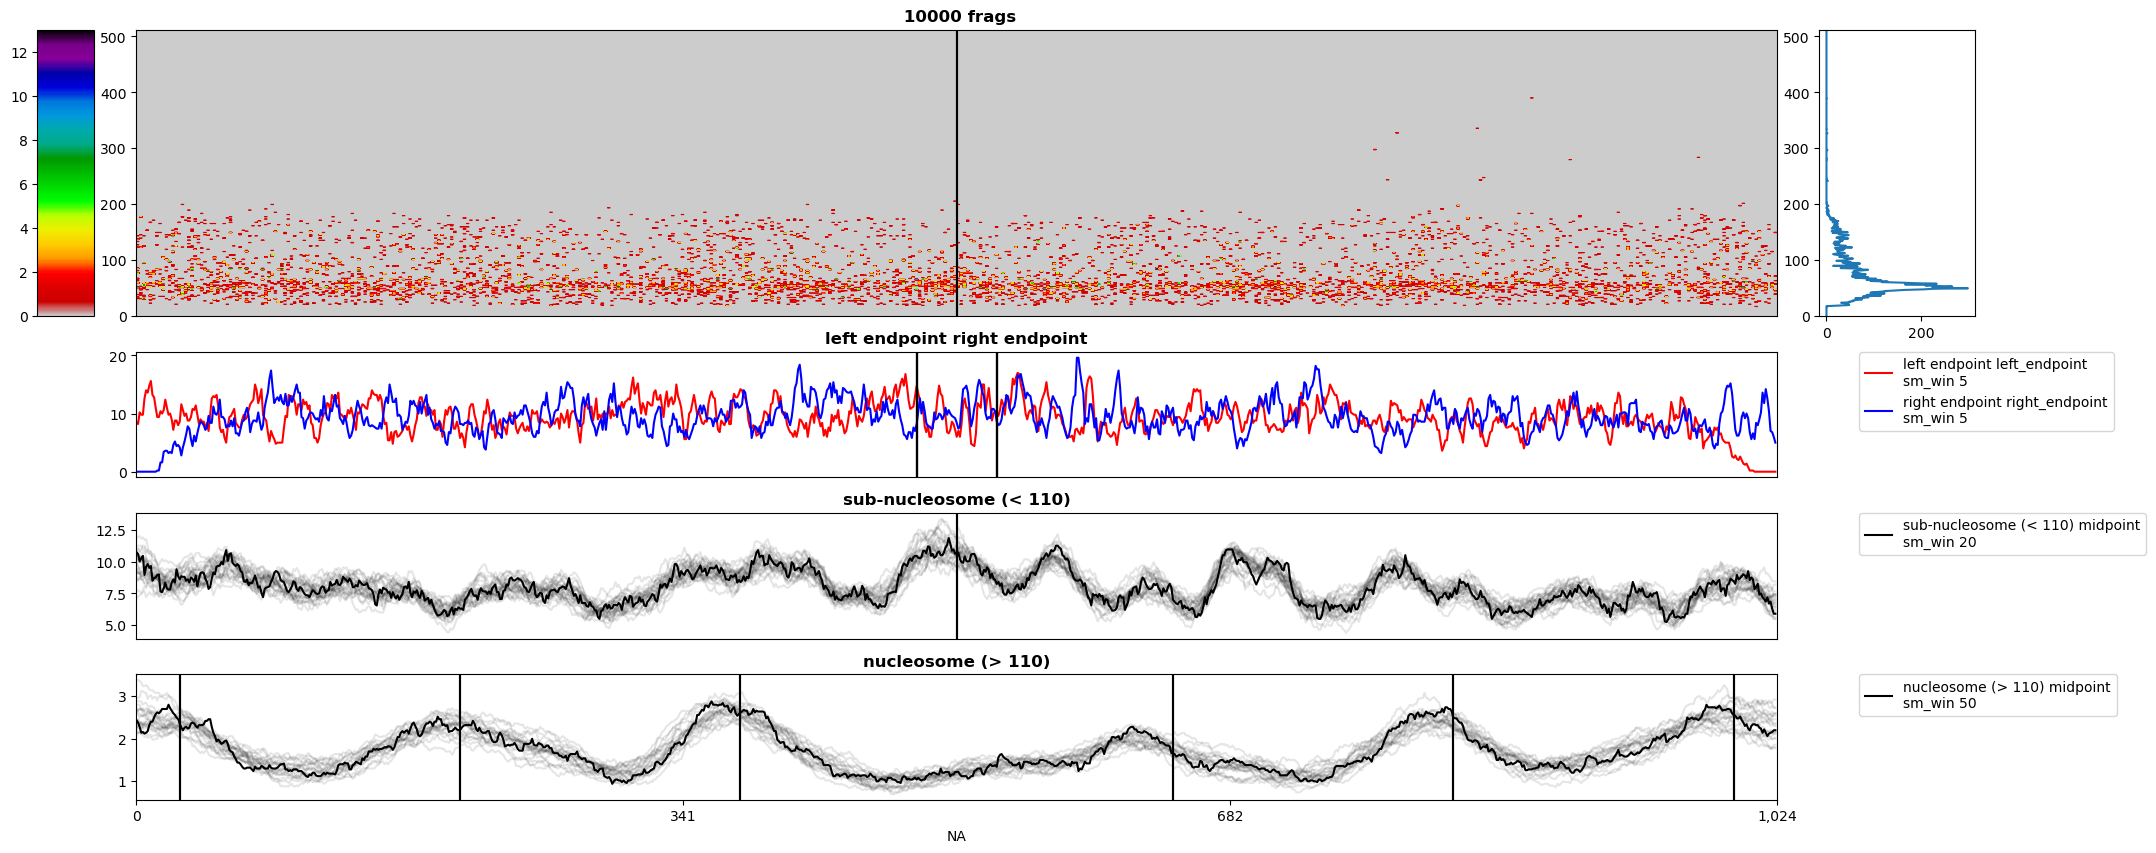

In [128]:
make_tracks(fm_from_regions_mask(only_blood_mask)).plot()

(<Figure size 2500x1000 with 6 Axes>,
 [<AxesSubplot:title={'center':' 10000 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (< 110)'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110)'}, xlabel='NA'>])

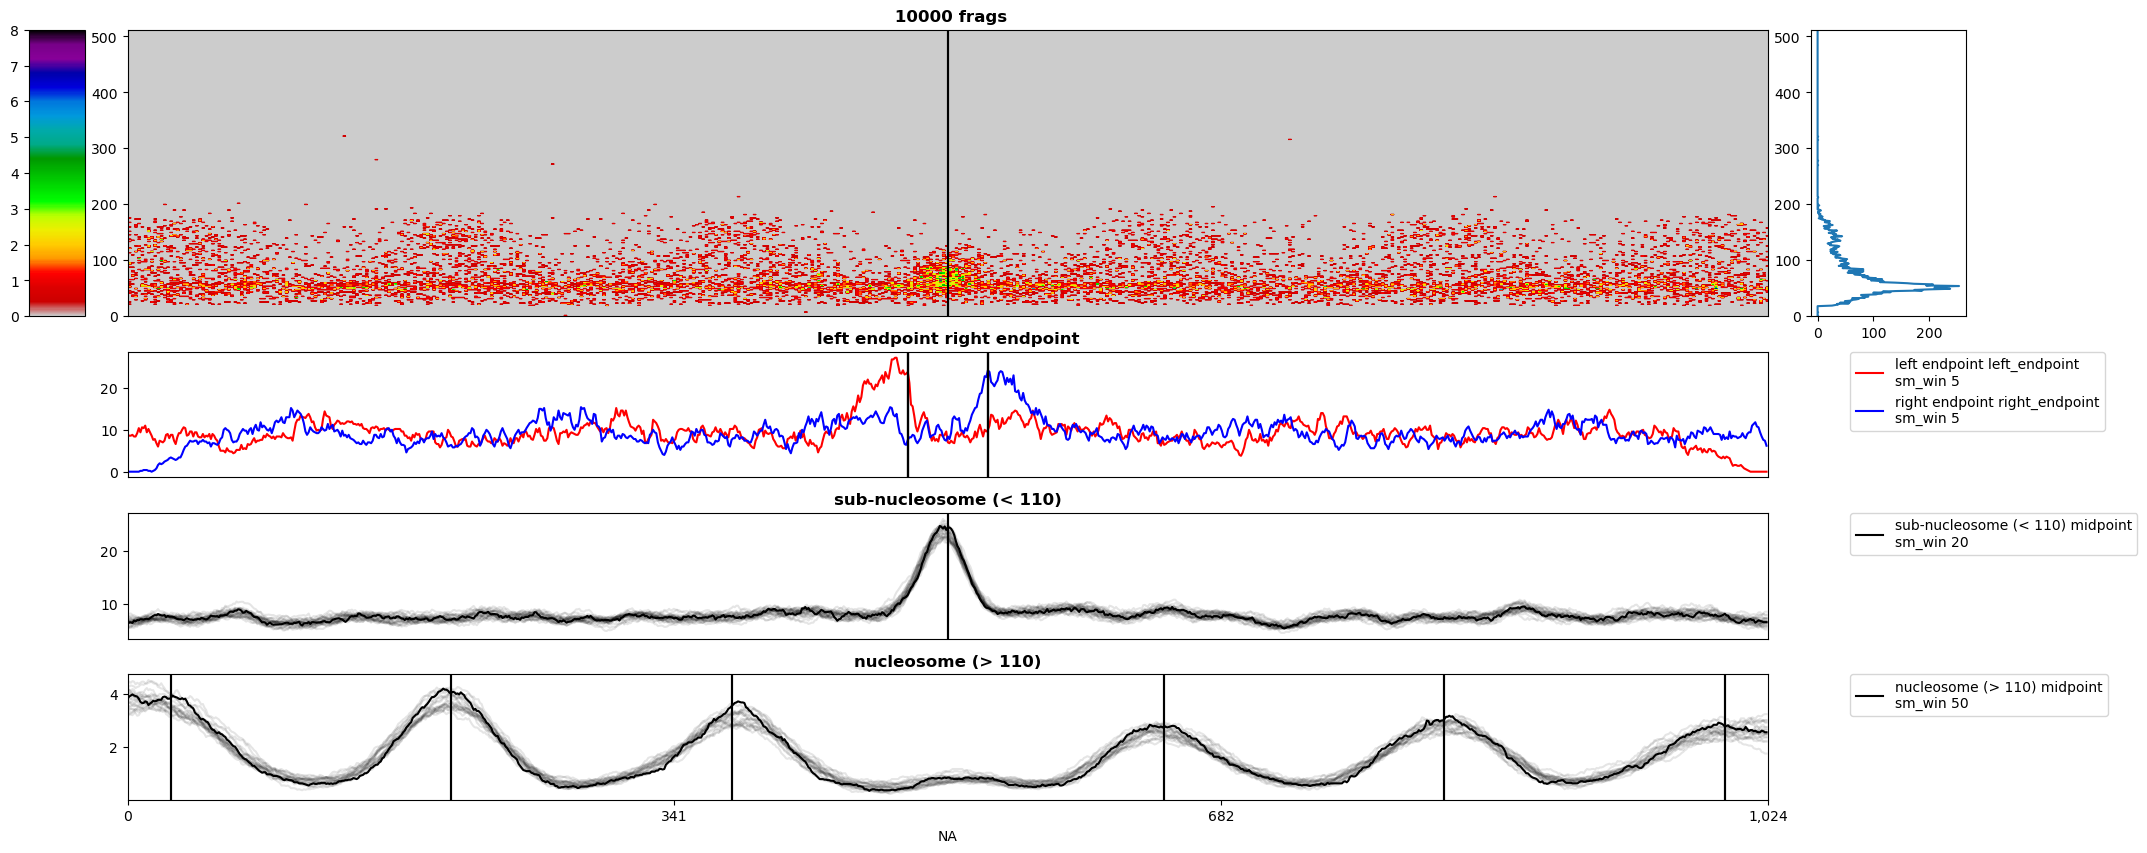

In [129]:
make_tracks(fm_from_regions_mask(all_bound_mask)).plot()

In [54]:
RegionFragmentArray.from_fragments_h5("/scratch/test_samples/SEQRUN48_LIBRARY574.fragments.h5", Region.from_region_str("chr1:91419-91436").resize(1024))

RegionFragmentArray(n_frags=112, region=chr1:90915-91939, length=1024, starts_0=[-415,-181, ..., 1022,1023], stops_0=[62,102, ..., 1167,1117], weights=[1.0,1.0, ..., 1.0,1.0], first_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], last_covered_base_weights=[1.0,1.0, ..., 1.0,1.0], cell_barcodes=[b'',b'', ..., b'',b''], strand=None, num_cpgs=[0,0, ..., 0,0], num_meth_cpgs=[0,0, ..., 0,0], max_frag_len=511)

In [142]:
neg_density = fm_from_regions_mask(only_neural_mask).sum_pooled(1).dense_array.clip(1e-5)
neg_density = neg_density/neg_density.sum()

In [143]:
pos_density = fm_from_regions_mask(only_blood_mask).sum_pooled(1).dense_array.clip(1e-5)
pos_density = pos_density/pos_density.sum()

In [144]:
neg_density.ravel()

array([3.33277956e-10, 3.33277956e-10, 3.33277956e-10, ..., 3.33277956e-10, 3.33277956e-10, 3.33277956e-10])

In [145]:
from numpy.random import multinomial as sample_multinomial
from scipy.stats import multinomial as multinomal_density
def sample(p, n):
    x = sample_multinomial(n, p.ravel())
    x.resize(p.shape)
    return x

In [154]:
n = 10000
disease_frac = 0.5
true = disease_frac*pos_density + (1-disease_frac)*neg_density
obs = sample(true, n)

multinomal_density.logpmf(obs.ravel(), obs.sum(), true.ravel())

array(-25213.05334977)

In [151]:
true.shape, obs.shape

((512, 1024), (512, 1024))

In [95]:
%load_ext autoreload
%autoreload 2
import os

from ravel.constants import REPO_DIR
from ravel.bio.features import load_tss_s_df, load_gene_expression_df
from ravel.public_data_resources.roadmap import CELL_ANATOMY_TO_CELL_EID

from ravel.data_manifest import DataManifest

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
tss_s = load_tss_s_df(ref='hg38')
tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301
1,chr1,169893923,169893924,ENSG00000000457.13_pk1,1000,-,ENSG00000000457,1,16.47,0.3748
2,chr1,169795042,169795043,ENSG00000000460.16_pk1,1000,+,ENSG00000000460,1,20.47,0.2621
3,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823
4,chr6,53545097,53545098,ENSG00000001084.10_pk1,1000,-,ENSG00000001084,1,17.27,0.9693
...,...,...,...,...,...,...,...,...,...,...
18272,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139
18273,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900
18274,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425
18275,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813


In [132]:
gene_expression = load_gene_expression_df(ref=REF).set_index("ens_id")
gene_expression

,ENC1,ENC2,ENC3,ENC4,ENC5,ENC6,ENC7,ENC8,ENC9,ENC10,...,E114,E116,E117,E118,E119,E120,E122,E123,E127,E128
ens_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,47.45,26.19,0.31,0.18,3.41,1.25,5.71,3.87,2.74,4.16,...,37.989,0.038,42.639,49.983,11.554,11.847,43.723,0.267,13.758,15.818
ENSG00000000005,0.04,0.00,0.00,0.00,0.09,0.23,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.018,0.000,0.006,0.000,0.000
ENSG00000000419,179.87,154.74,24.58,20.34,4.21,1.64,16.48,13.09,12.21,8.39,...,52.215,79.197,107.098,62.811,42.386,54.869,16.652,73.719,56.578,56.371
ENSG00000000457,8.15,7.69,1.86,2.30,2.32,0.53,0.56,0.46,0.36,0.56,...,4.829,11.082,8.814,2.646,2.483,2.527,2.549,7.651,4.967,3.714
ENSG00000000460,26.32,18.98,1.22,1.18,0.92,0.32,3.59,2.61,1.82,3.41,...,8.001,13.743,25.369,3.373,4.646,2.179,4.099,22.103,3.290,2.491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000259667,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.032,0.000,0.000,0.000,0.006,0.000
ENSG00000259718,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ENSG00000259741,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,74.923,22.036,23.527,16.770,25.595,57.260,15.039,8.164,31.558,57.093


In [133]:
from itertools import chain
gi_cell_eids = sorted(x for x in set(chain(*[CELL_ANATOMY_TO_CELL_EID[x] for x in ['gi_duodenum', 'gi_colon', 'gi_rectum', 'gi_stomach', 'gi_intestine', 'gi_esophagus']])) if x in gene_expression.columns)
blood_cell_eids = sorted(x for x in CELL_ANATOMY_TO_CELL_EID['blood'] if x in gene_expression.columns)

In [135]:
gi_cell_eids, blood_cell_eids

(['E079', 'E094', 'E106', 'E109'],
 ['E037', 'E038', 'E047', 'E050', 'E062', 'E116', 'E123'])

In [142]:
all_on_mask = (gene_expression[gi_cell_eids].min(axis=1) > 1) & ((gene_expression[blood_cell_eids].min(axis=1) > 1))
all_on_mask

ens_id
ENSG00000000003    False
ENSG00000000005    False
ENSG00000000419     True
ENSG00000000457     True
ENSG00000000460     True
                   ...  
ENSG00000259667    False
ENSG00000259718    False
ENSG00000259741     True
ENSG00000259765    False
ENSG00000259766    False
Length: 61338, dtype: bool

In [143]:
tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness,...,E114,E116,E117,E118,E119,E120,E122,E123,E127,E128
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301,...,52.215,79.197,107.098,62.811,42.386,54.869,16.652,73.719,56.578,56.371
1,chr1,169893923,169893924,ENSG00000000457.13_pk1,1000,-,ENSG00000000457,1,16.47,0.3748,...,4.829,11.082,8.814,2.646,2.483,2.527,2.549,7.651,4.967,3.714
2,chr1,169795042,169795043,ENSG00000000460.16_pk1,1000,+,ENSG00000000460,1,20.47,0.2621,...,8.001,13.743,25.369,3.373,4.646,2.179,4.099,22.103,3.290,2.491
3,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823,...,26.622,0.002,124.801,0.007,0.419,39.724,8.464,41.504,1.348,32.725
4,chr6,53545097,53545098,ENSG00000001084.10_pk1,1000,-,ENSG00000001084,1,17.27,0.9693,...,46.023,4.571,10.435,10.065,18.571,1.547,2.588,2.750,22.945,5.273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9119,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9120,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9121,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9122,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [145]:
tss_s = tss_s.query("num_tss_in_gene == 1").merge_gene_expression(gene_expression).set_binary_label_by_thresholds(
    blood_cell_eids,
    on_threshold=25,
    off_threshold=.1,
    drop_unlabeled_records=True,
)

#tss_s = tss_s
#tss_s.query('label == 1').head()

In [146]:
tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness,...,E116,E117,E118,E119,E120,E122,E123,E127,E128,label
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301,...,79.197,107.098,62.811,42.386,54.869,16.652,73.719,56.578,56.371,1
14,chr17,38870053,38870054,ENSG00000002834.17_pk1,1000,+,ENSG00000002834,1,317.87,0.8141,...,36.552,33.768,70.159,85.268,128.565,144.330,49.802,86.640,143.304,1
20,chr8,17497116,17497117,ENSG00000003989.16_pk1,1000,+,ENSG00000003989,1,2.62,0.6914,...,0.022,143.656,96.700,0.055,5.733,12.632,0.004,0.377,1.007,0
21,chr7,127588432,127588433,ENSG00000004059.10_pk1,1000,+,ENSG00000004059,1,39.73,0.5661,...,63.560,50.741,81.860,198.680,89.048,230.688,108.866,124.927,65.374,1
38,chrX,119468442,119468443,ENSG00000005022.5_pk1,1000,+,ENSG00000005022,1,529.56,0.9413,...,245.466,363.616,308.007,579.936,217.723,453.416,401.333,331.893,200.428,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9119,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
9120,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
9121,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
9122,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
